# First Model

What we've figured out:
- SMOTE: stick to 'minority' rather than 'not majority' setting, keep k value the same
- We've fixed hyperparameters (batch size, epochs, LR), model architecture (num layers, dims, dropout), features (rolling window size), train-val-test split sizes

In [1]:
import pandas as pd
import torch
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack
from torch import nn
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from imblearn.over_sampling import SMOTE

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## Collect the data

In [3]:
# read the csvs
beige_df = pd.read_csv("data/beige_book_1996_2025.csv")
labels_df = pd.read_csv("data/filtered_labels.csv")
lm_sentiment_df = pd.read_csv('data/beige_book_sentiment_scores_1996_2025.csv')
market_futures_df = pd.read_csv('data/futures_with_diff.csv')

# column to merge on is timestamp
labels_df['timestamp'] = labels_df['observation_date']
market_futures_df['timestamp'] = market_futures_df['exp_date']
beige_df = pd.merge(beige_df, labels_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, lm_sentiment_df, on='timestamp', how='inner')
beige_df = pd.merge(beige_df, market_futures_df, on='timestamp', how='inner')

# process the columns
beige_df['text'] = beige_df['text_x']
beige_df['url'] = beige_df['url_x']
beige_df['month'] = beige_df['month_x']
beige_df['year'] = beige_df['year_x']
beige_df = beige_df.drop(['year_x', 'month_x', 'url_x', 'text_x'], axis=1)
beige_df = beige_df.drop(['Unnamed: 0', 'Unnamed: 0_x', 'Unnamed: 0_y', 'observation_date', 'exp_date'], axis=1)
beige_df = beige_df.drop(['year_y', 'month_y', 'url_y', 'text_y'], axis=1)

# add average for new columns
beige_df['negative_score_10_mean'] = beige_df['negative_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['positive_score_10_mean'] = beige_df['positive_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['uncertainty_score_10_mean'] = beige_df['uncertainty_score'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['futures_price_10_mean'] = beige_df['futures_price'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['implied_rate_10_mean'] = beige_df['implied_rate'].rolling(window=24, min_periods=1).mean().shift(1)
beige_df['implied_rate_diff_10_mean'] = beige_df['implied_rate_diff'].rolling(window=24, min_periods=1).mean().shift(1)

beige_df = beige_df.drop(index=0) # first row is na

# sort by timestamp
final_df = beige_df.sort_values(by='timestamp')

print(len(final_df))
print(final_df.columns)
final_df.head()

231
Index(['timestamp', 'rate', 'decision', 'negative_score', 'positive_score',
       'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
       'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
       'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
       'uncertainty_score_10_mean', 'futures_price_10_mean',
       'implied_rate_10_mean', 'implied_rate_diff_10_mean'],
      dtype='object')


,timestamp,rate,decision,negative_score,positive_score,uncertainty_score,52W_high,52W_low,52W_pct_chg,futures_price,...,text,url,month,year,negative_score_10_mean,positive_score_10_mean,uncertainty_score_10_mean,futures_price_10_mean,implied_rate_10_mean,implied_rate_diff_10_mean
1,1996-12-01,5.25,hold,0.014639,0.024703,0.007319,95.52,94.00,-0.62,94.660,...,moderate economic growth continues to be repor...,https://www.federalreserve.gov/fomc/beigebook/...,12,1996,0.029883,0.029883,0.010204,94.750000,5.250000,-0.04500
2,1997-01-01,5.25,hold,0.035156,0.026367,0.004883,95.52,93.90,-0.63,94.745,...,most district reports characterized early autu...,https://www.federalreserve.gov/fomc/beigebook/...,1,1997,0.022261,0.027293,0.008762,94.705000,5.295000,-0.01750
3,1997-03-01,5.25,hold,0.023581,0.020087,0.006114,94.73,93.68,0.57,94.635,...,district economies generally continue to expan...,https://www.federalreserve.gov/fomc/beigebook/...,3,1997,0.026559,0.026984,0.007469,94.718333,5.281667,-0.04000
4,1997-05-01,5.50,raise,0.027429,0.028997,0.001567,94.70,93.79,0.54,94.490,...,district economies generally continued to expa...,https://www.federalreserve.gov/fomc/beigebook/...,5,1997,0.025815,0.025260,0.007130,94.697500,5.302500,0.01625
5,1997-06-01,5.50,hold,0.031159,0.018116,0.005797,94.68,94.29,0.10,94.465,...,all twelve district economies expanded in may ...,https://www.federalreserve.gov/fomc/beigebook/...,6,1997,0.026138,0.026007,0.006017,94.656000,5.344000,0.01300


# Feature Engineering

In [4]:
# standardize the labels (so numeric labels of 0, 1, 2) - raise: 2, hold: 0, lower: 1
label_encoder = LabelEncoder()
final_df['labels'] = label_encoder.fit_transform(final_df['decision'])

In [5]:
# train-test split (70-15-15 split)
X = final_df[['timestamp', 'rate', 'negative_score', 'positive_score',
        'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg',
        'futures_price', 'implied_rate', 'implied_rate_diff', 'text', 'url',
        'month', 'year', 'negative_score_10_mean', 'positive_score_10_mean',
        'uncertainty_score_10_mean', 'futures_price_10_mean',
        'implied_rate_10_mean', 'implied_rate_diff_10_mean']]
y = final_df['labels']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, random_state=seed, test_size=0.3, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, random_state=seed, test_size=0.5, shuffle=True)

print(len(X_train), len(X_val), len(X_test))

161 35 35


In [6]:
# generate TF-IDF encodings for the text
tf_idf_vectorizer = TfidfVectorizer()
X_text_train = tf_idf_vectorizer.fit_transform(X_train['text'])
X_text_val = tf_idf_vectorizer.transform(X_val['text'])
X_text_test = tf_idf_vectorizer.transform(X_test['text'])

print(X_text_train.shape, X_text_val.shape, X_text_test.shape)


(161, 8602) (35, 8602) (35, 8602)


In [7]:
scaler = StandardScaler()
columns_to_scale = ['rate', 'negative_score', 'positive_score', 'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg', 
        'futures_price', 'implied_rate', 'implied_rate_diff', 'negative_score_10_mean', 'positive_score_10_mean',
        'uncertainty_score_10_mean', 'futures_price_10_mean', 'implied_rate_10_mean', 'implied_rate_diff_10_mean']

X_nums_train = scaler.fit_transform(X_train[columns_to_scale])
X_nums_val   = scaler.transform(X_val[columns_to_scale])
X_nums_test  = scaler.transform(X_test[columns_to_scale])

print(X_nums_train.shape, X_nums_val.shape, X_nums_test.shape)

(161, 16) (35, 16) (35, 16)


In [8]:
X_train = hstack([X_nums_train, X_text_train])
X_val = hstack([X_nums_val, X_text_val])
X_test = hstack([X_nums_test, X_text_test])

print(X_train.shape, X_val.shape, X_test.shape)

(161, 8618) (35, 8618) (35, 8618)


In [9]:
# SMOTE stuff
smote = SMOTE(sampling_strategy='minority', random_state=seed)
X_train, y_train = smote.fit_resample(X_train, y_train)

## Make the model

In [10]:
class FirstExperimentModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # input layer, starting with 512 since i've not seen 1024 before
        self.input_layer = nn.Sequential(nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.3))

        # hidden layers, reducing dims further
        self.hidden_layer = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3))
        self.hidden_layer_2 = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.3))

        # output layer without softmax
        self.output_layer = nn.Linear(32, 3)

        # all together now
        self.net = nn.Sequential(self.input_layer, self.hidden_layer, self.hidden_layer_2, self.output_layer)
    
    def forward(self, x):
        return self.net(x)
    
model = FirstExperimentModel(X_train.shape[1])
model.to(device)
print(model.net)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=8618, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (1): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (2): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (3): Linear(in_features=32, out_features=3, bias=True)
)


In [11]:
# define cost-sensitive loss function
# inspiration: https://medium.com/nerd-for-tech/review-cb-loss-class-balanced-loss-based-on-effective-number-of-samples-image-classification-3056a1a1a001
weights = 1.0 / np.bincount(y_train.values)
weights = weights / weights.sum()
weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))

lr = 0.0001 # making this v small since we have less data
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

/var/folders/fh/d8z4d5wn6l51hqgtfycpk26r0000gn/T/ipykernel_80097/2746057137.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=device))


## Training Loop

TODO: figure out how to save the best model by tracking the best validation error seen per epoch

In [12]:
num_epochs = 50 # idk apparently for tf-idf you need large epochs
batch_size = 32 # this is sort of random (smaller might work better since we have less data to begin with)

In [13]:
# heavily copied from HW4

def train(data_loader, model, criterion, optimizer, device):
    train_avg_loss = 0
    num_correct = 0
    all_preds = []
    all_labels = []

    model.train()
    for feats, labels in data_loader:
        optimizer.zero_grad()
        feats = feats.to(device)
        labels = labels.long().to(device)

        # Perform forward pass and calculate avg loss over all time steps
        logits = model(feats)
        loss = criterion(logits, labels)
        preds = torch.argmax(logits, dim=1)
        num_correct += torch.sum(preds == labels)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        # Backward pass, update weights
        loss.backward()
        optimizer.step()

        train_avg_loss += loss.item()*feats.shape[0]

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = num_correct.item() / len(data_loader.dataset)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Train loss: {train_avg_loss/len(data_loader.dataset)} | Accuracy: {accuracy} | Precision: {precision} | Recall: {recall} | F1: {f1}")
    return train_avg_loss/len(data_loader.dataset)

def val(data_loader, model, criterion, device):
    val_avg_loss = 0
    num_correct = 0
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in data_loader:
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass and calculate avg loss over all time steps
            logits = model(feats)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)
            num_correct += torch.sum(preds == labels)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

            val_avg_loss += loss.item()*feats.shape[0]

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = num_correct.item() / len(data_loader.dataset)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"Val loss: {val_avg_loss/len(data_loader.dataset)} | Accuracy: {accuracy} | Precision: {precision} | Recall: {recall} | F1: {f1}\n")
    return val_avg_loss/len(data_loader.dataset)

In [ ]:
X_train_dense = torch.tensor(X_train.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
train_dataset = TensorDataset(X_train_dense, y_train_tensor)

X_val_dense = torch.tensor(X_val.toarray(), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
val_dataset = TensorDataset(X_val_dense, y_val_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

train_loss_list, val_loss_list = [], []
for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_loss_list.append(train(train_dataloader, model, criterion, optimizer, device))
    val_loss_list.append(val(val_dataloader, model, criterion, device))

with open('model_data/scores.txt', 'a') as f:
    f.write(f"{batch_size}-{num_epochs}-{lr} | {train_loss_list} | {val_loss_list}\n")

Epoch 0
Train loss: 1.103224886297689 | Accuracy: 0.4279835390946502 | Precision: 0.14266117969821673 | Recall: 0.3333333333333333 | F1: 0.19980787704130643
Val loss: 1.1765511785234724 | Accuracy: 0.02857142857142857 | Precision: 0.009523809523809523 | Recall: 0.3333333333333333 | F1: 0.018518518518518517

Epoch 1
Train loss: 1.0997275962751099 | Accuracy: 0.4279835390946502 | Precision: 0.14266117969821673 | Recall: 0.3333333333333333 | F1: 0.19980787704130643
Val loss: 1.172677183151245 | Accuracy: 0.02857142857142857 | Precision: 0.009523809523809523 | Recall: 0.3333333333333333 | F1: 0.018518518518518517

Epoch 2
Train loss: 1.0974372497801919 | Accuracy: 0.4279835390946502 | Precision: 0.14266117969821673 | Recall: 0.3333333333333333 | F1: 0.19980787704130643
Val loss: 1.1684618643351963 | Accuracy: 0.02857142857142857 | Precision: 0.009523809523809523 | Recall: 0.3333333333333333 | F1: 0.018518518518518517

Epoch 3
Train loss: 1.094624053303597 | Accuracy: 0.4279835390946502 | P

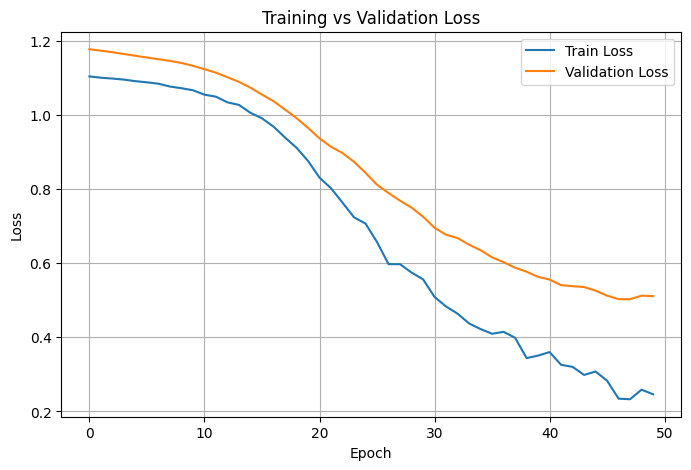

In [15]:
plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
def actual_vs_pred(data_loader, model, device):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for feats, labels in tqdm(data_loader):
            feats = feats.to(device)
            labels = labels.long().to(device)

            # Perform forward pass
            logits = model(feats)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return pd.DataFrame({"actual": all_labels, "predicted": all_preds})

actual_vs_pred(val_dataloader, model, device)

100%|██████████| 2/2 [00:00<00:00, 773.07it/s]


,actual,predicted
0,0,2
1,0,0
2,0,0
3,0,0
4,0,1
5,0,0
6,2,2
7,0,0
8,0,0
9,2,2


## Test dataset

In [17]:
X_test_dense = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
test_dataset = TensorDataset(X_test_dense, y_test_tensor)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
results = actual_vs_pred(test_dataloader, model, device)

100%|██████████| 2/2 [00:00<00:00, 949.80it/s]


In [18]:
print(f"Test Accuracy: {accuracy_score(results["actual"], results["predicted"])}")
print(f"Test Precision: {precision_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test Recall: {recall_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test f1: {f1_score(results["actual"], results["predicted"], average="macro")}")
print(f"Test conf_matrix:\n{confusion_matrix(results["actual"], results["predicted"])}")

Test Accuracy: 0.9142857142857143
Test Precision: 0.9666666666666667
Test Recall: 0.7999999999999999
Test f1: 0.8395989974937343
Test conf_matrix:
[[27  0  0]
 [ 3  2  0]
 [ 0  0  3]]


## SHAP

In [19]:
background_inputs = []
for feats, _ in train_dataloader:
    background_inputs.append(feats)
background_data = torch.cat(background_inputs, dim=0).to(device)

test_inputs = []
for feats, _ in test_dataloader:
    test_inputs.append(feats)
test_data = torch.cat(test_inputs, dim=0).to(device)

explainer = shap.DeepExplainer(model, background_data)
shap_values = explainer.shap_values(test_data)

numeric_feature_names = columns_to_scale
tfidf_feature_names = tf_idf_vectorizer.get_feature_names_out().tolist()
feature_names = numeric_feature_names + tfidf_feature_names
print(feature_names)

['rate', 'negative_score', 'positive_score', 'uncertainty_score', '52W_high', '52W_low', '52W_pct_chg', 'futures_price', 'implied_rate', 'implied_rate_diff', 'negative_score_10_mean', 'positive_score_10_mean', 'uncertainty_score_10_mean', 'futures_price_10_mean', 'implied_rate_10_mean', 'implied_rate_diff_10_mean', '000', '10', '100', '1000', '104', '105', '11', '110', '119', '11retail', '12', '120', '125', '128', '12th', '13', '130', '138', '14', '140', '15', '150', '16', '160', '17', '170', '18', '185', '187', '19', '190', '195', '1976', '1990s', '1995', '1996', '1997', '1998', '1999', '20', '200', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2011q1', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '21', '22', '220', '225', '23', '230', '23rd', '24', '25', '250', '26', '27', '28', '280', '29', '2nd', '2percent', '30', '300', '31', '32', '325', '33', '330', '34',

In [20]:
shap_values.shape # (num test samples x num features x num classes)

(35, 8618, 3)

In [21]:
# axes swapping: https://medium.com/@muneebhashmi10/explainable-convolutional-neural-networks-with-pytorch-shap-62ffb229a918
def top_features_per_class(shap_values, feature_names, top_k):
    N, F, C = shap_values.shape
    
    results = {}
    for cls in range(C):
        vals = shap_values[:, :, cls]
        mean_abs = np.mean(np.abs(vals), axis=0)  # shape (F,)
        idx = np.argsort(-mean_abs)[:top_k]
        results[cls] = list(zip(np.array(feature_names)[idx], mean_abs[idx]))
    
    return results

top_feats = top_features_per_class(shap_values, feature_names, 20)

for cls, feats in top_feats.items():
    print(f"\nTop features for class {cls}:")
    for f, score in feats:
        print(f"{f:25s} {score:.6f}")


Top features for class 0:
implied_rate_diff         0.134888
positive_score            0.080532
uncertainty_score_10_mean 0.077386
rate                      0.073804
futures_price             0.067929
implied_rate              0.066904
negative_score            0.063568
implied_rate_10_mean      0.062611
52W_high                  0.061697
futures_price_10_mean     0.058444
implied_rate_diff_10_mean 0.051295
negative_score_10_mean    0.046499
positive_score_10_mean    0.043724
in                        0.015500
the                       0.012941
to                        0.009985
52W_pct_chg               0.009803
52W_low                   0.009348
are                       0.007558
dallas                    0.007151

Top features for class 1:
implied_rate_diff         0.691539
implied_rate_10_mean      0.550026
futures_price_10_mean     0.542336
positive_score_10_mean    0.287488
uncertainty_score_10_mean 0.238228
positive_score            0.209143
52W_high                  0.150886
r

/var/folders/fh/d8z4d5wn6l51hqgtfycpk26r0000gn/T/ipykernel_80097/353094675.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


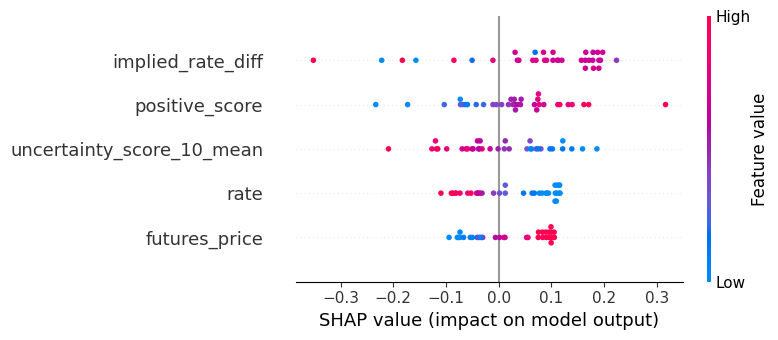

In [22]:
shap.summary_plot(
    shap_values[:, :, 0],
    test_data.cpu().numpy(),
    feature_names=feature_names,
    max_display=5
)

/var/folders/fh/d8z4d5wn6l51hqgtfycpk26r0000gn/T/ipykernel_80097/338359395.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


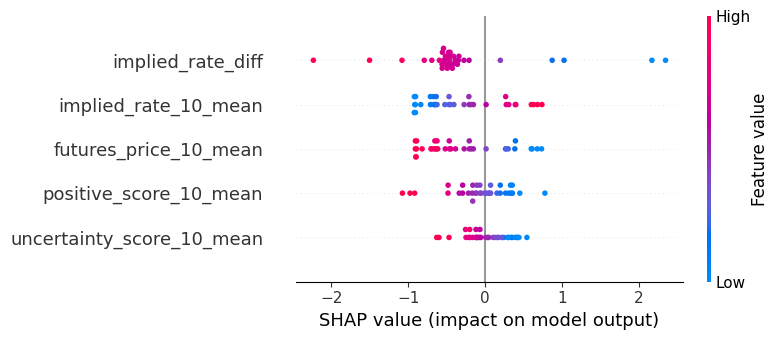

In [23]:
shap.summary_plot(
    shap_values[:, :, 1],
    test_data.cpu().numpy(),
    feature_names=feature_names,
    max_display=5
)

/var/folders/fh/d8z4d5wn6l51hqgtfycpk26r0000gn/T/ipykernel_80097/551641353.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


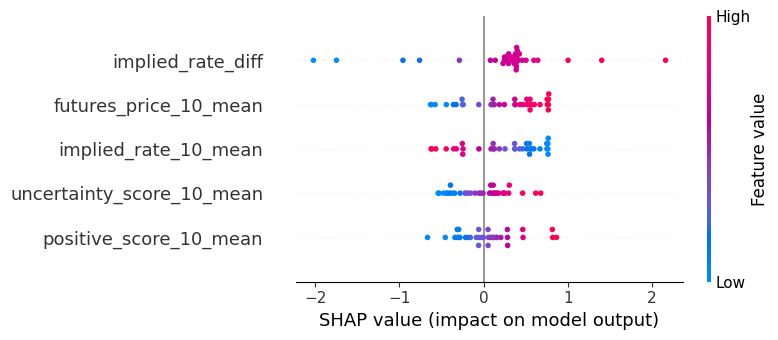

In [24]:
shap.summary_plot(
    shap_values[:, :, 2],
    test_data.cpu().numpy(),
    feature_names=feature_names,
    max_display=5
)